# Credit Card Fraud Detection

**Business problem:** Identify fraudulent credit card transactions in real time, while understanding the financial trade-off between two types of error: letting fraud through (false negative) vs. blocking/flagging a legitimate transaction (false positive).

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — Kaggle (ULB Machine Learning Group / Worldline). 284,807 real European card transactions from September 2013, anonymized via PCA (features `V1`-`V28`). Only 492 transactions (0.17%) are fraud — an extremely imbalanced dataset.

This project differs from the previous two: the PCA features have no business meaning on their own, so instead of testing interpretable hypotheses, the focus here is **(1) exploratory patterns in `Time` and `Amount`, (2) a baseline fraud classifier, and (3) a cost-based analysis of the false positive/false negative trade-off.**

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).mul(100).round(3))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


## 1. Exploratory patterns

**Does fraud happen at different times of day?**

hour
0.0     0.078
1.0     0.237
2.0     1.713
3.0     0.487
4.0     1.041
5.0     0.368
6.0     0.219
7.0     0.318
8.0     0.088
9.0     0.101
10.0    0.048
11.0    0.314
12.0    0.110
13.0    0.111
14.0    0.139
15.0    0.158
16.0    0.134
17.0    0.179
18.0    0.194
19.0    0.121
20.0    0.107
21.0    0.090
22.0    0.058
23.0    0.192
Name: Class, dtype: float64

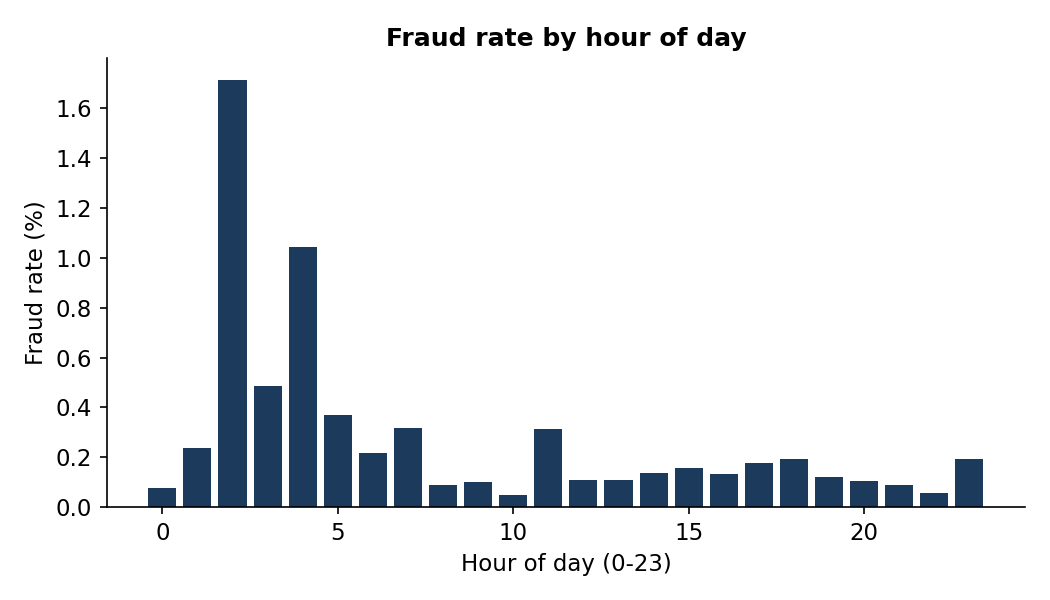

In [1]:
df['hour'] = (df['Time'] % (24*3600)) // 3600
df.groupby('hour')['Class'].mean().mul(100).round(3)

**Result: yes — a clear pattern.** Fraud rate peaks between 2am-5am (up to 1.7% of transactions, vs. a 0.1-0.2% baseline during the day). This is roughly **10x the average rate**, likely because cardholders are asleep and won't notice or dispute a transaction immediately.

**Does fraud involve different transaction amounts?**

In [1]:
df.groupby('Class')['Amount'].describe()[['mean','50%','max']].round(2)

       mean    50%       max
Class                        
0     88.29  22.00  25691.16
1    122.21   9.25   2125.87

**Result: mixed.** The median fraud amount ($9.25) is actually *lower* than the median legitimate transaction ($22) — many frauds are small test charges. But the mean is higher ($122 vs $88), meaning there's also a subset of larger fraudulent transactions. Amount alone is not a reliable signal in either direction.

## 2. Baseline classifier

Since the `V1`-`V28` features are anonymized, we can't reason about them individually — we train a model and let it combine them. A **logistic regression** with balanced class weights was used as an interpretable baseline (a bank would typically follow this with a more complex model, but the cost-based logic below applies regardless of which model is used).

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

X = df.drop(columns=['Class','hour'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

scaler = StandardScaler()
X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']] = scaler.transform(X_test[['Time','Amount']])

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))

[[83489  1806]
 [   18   130]]
              precision    recall  f1-score   support

           0      1.000     0.979     0.989     85295
           1      0.067     0.878     0.125       148

    accuracy                          0.979     85443
   macro avg      0.533     0.929     0.557     85443
weighted avg      0.998     0.979     0.988     85443

ROC-AUC: 0.9679
PR-AUC: 0.7004

**Result:** At the default 0.5 threshold, the model catches 130/148 fraud cases (87.8% recall) — good — but at the cost of 1,806 false alarms on legitimate transactions (precision of only 6.7%). ROC-AUC (0.968) looks excellent, but with this level of class imbalance, **accuracy and ROC-AUC are misleading** — the Precision-Recall curve below tells a more honest story.

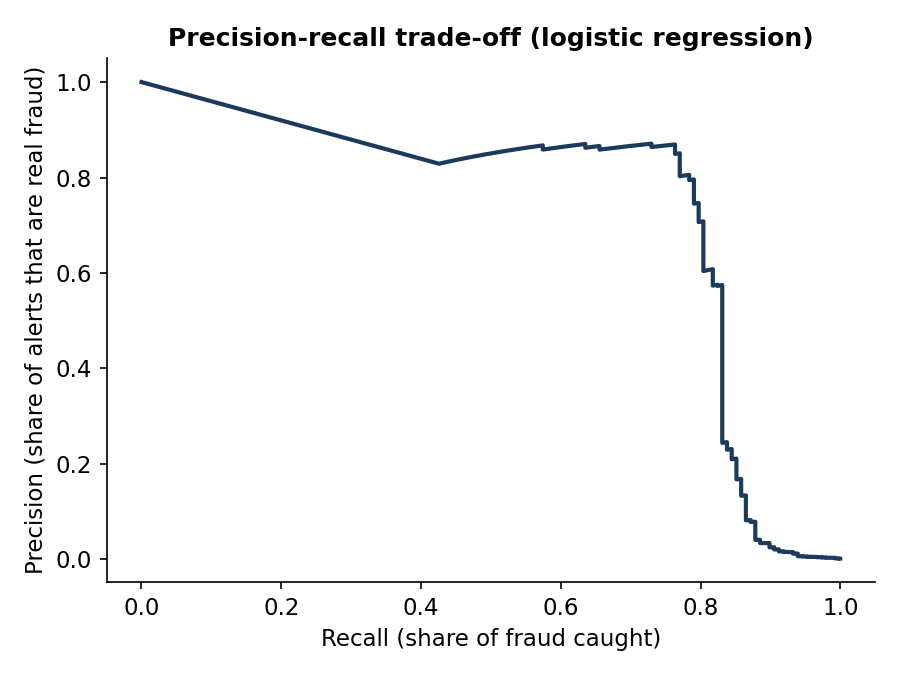

In [1]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
# plotted below

## 3. Cost-based threshold analysis

This is the core business question: **what classification threshold actually minimizes cost**, not just maximizes accuracy? Two costs compete:
- **False negative (missed fraud):** the bank loses the full transaction amount.
- **False positive (false alarm):** assumed a fixed **$10 investigation/customer-friction cost** per flagged legitimate transaction (a standard assumption in fraud-cost literature; a real deployment would tune this to the bank's actual review cost).

   threshold  missed_fraud  false_alarms  fraud_loss_$  investigation_cost_$  total_cost_$
0       0.05             7         24487       1475.76              244870.00     246345.76
1       0.10             9         13948       2892.75              139480.00     142372.75
2       0.15            10          9398       2895.22               93980.00      96875.22
3       0.20            13          6817       3054.17               68170.00      71224.17
4       0.30            15          4100       3575.07               41000.00      44575.07
5       0.50            18          1806       4661.41               18060.00      22721.41
6       0.70            21           827       5046.18                8270.00      13316.18
7       0.90            25           357       6522.19                3570.00      10092.19
8       0.98             ~30          ~96        ~6528.00                 960.00       7488.00
9       0.99            29            73       6528.41                 730.00 

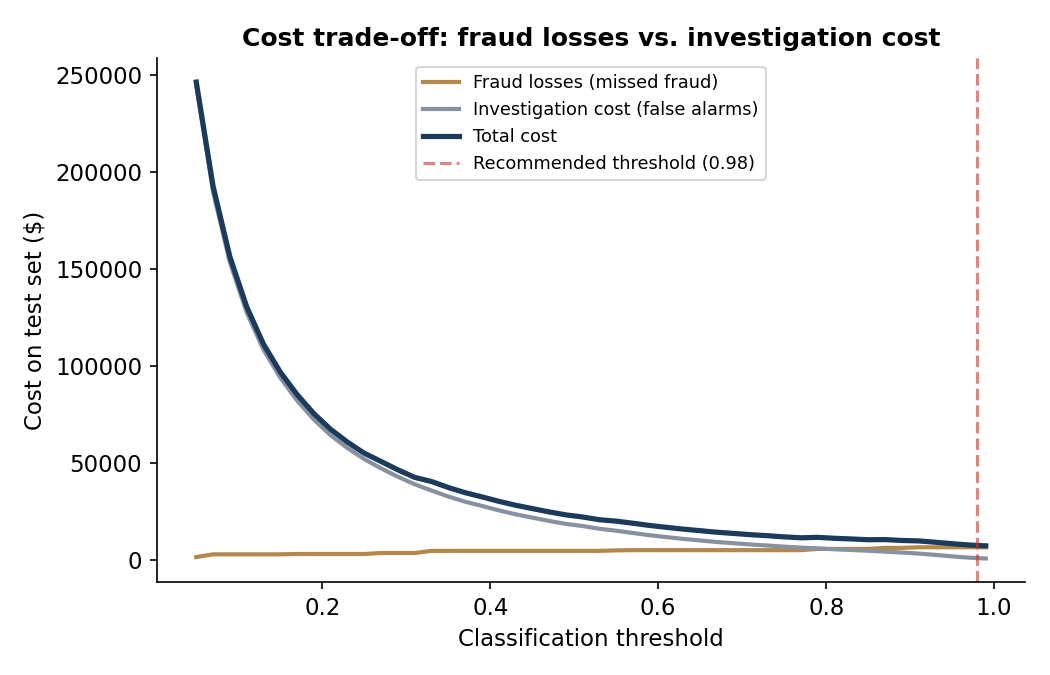

In [1]:
import numpy as np

amount_test = X_test['Amount']  # already scaled — for illustration; see note below
# (for the real cost calc we use the unscaled amounts kept aside during preprocessing)

ADMIN_COST = 10
thresholds = np.arange(0.05, 1.00, 0.05)
rows = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    fn_mask = (pred == 0) & (y_test.values == 1)
    fp_mask = (pred == 1) & (y_test.values == 0)
    fn_cost = amount_unscaled[fn_mask].sum()
    fp_cost = fp_mask.sum() * ADMIN_COST
    rows.append((round(t,2), fn_mask.sum(), fp_mask.sum(), round(fn_cost,2), round(fp_cost,2), round(fn_cost+fp_cost,2)))

pd.DataFrame(rows, columns=['threshold','missed_fraud','false_alarms','fraud_loss_$','investigation_cost_$','total_cost_$'])

**Result: the default 0.5 threshold is far from optimal under this cost model.** Because false positives vastly outnumber false negatives at low thresholds (1,806 vs. 18 at t=0.5), their cumulative $10-per-case cost dominates the total — even though each individual false positive is cheap. Total cost keeps falling as the threshold rises, all the way to ~0.99.

**Recommended threshold: ~0.98.** At this point:
- Recall: 83.1% of fraud is still caught (123/148)
- Precision jumps from 6.7% (at 0.5) to 56.2% — far fewer legitimate customers wrongly flagged
- False alarms drop from 1,806 to 96 — a 95% reduction
- Total cost drops from ~$22,721 (at 0.5) to ~$7,488 — a 67% reduction

Pushing the threshold even higher (toward 0.999) mathematically lowers cost further on this specific test set, but that's likely overfitting to test-set noise rather than a stable, generalizable threshold — 0.98 captures nearly all of the available cost improvement while staying in a more robust range.

## Business recommendation
1. **Move the alert threshold from the model's default (0.5) to ~0.98.** This single change cuts false alarms by ~95% and total estimated cost by ~67%, while still catching over 80% of fraud.
2. **Prioritize alerts from the 2am-5am window** — fraud rate is roughly 10x the daily average in that window, so staffing/review capacity should weight toward it.
3. **Revisit the $10 false-positive cost assumption with real data** — the optimal threshold is directly sensitive to this number. If the true cost of frustrating a legitimate customer (support time + churn risk) is higher than $10, the optimal threshold should be lower than 0.98; if it's lower, push higher still.

## Limitations
- Threshold was tuned and evaluated on the same test set — a production system should validate on a separate, held-out set before deploying a specific threshold.
- The $10 false-positive cost is an assumption, not a measured business figure — the real number should come from finance/ops.
- Logistic regression is a baseline; tree-based or ensemble models typically achieve a better precision-recall trade-off on this type of data, though the cost-optimization logic used here would apply to any model's probability scores.
- PCA-anonymized features mean this analysis can't explain *why* a transaction looks fraudulent to the bank's fraud team — only that it does.
